In [394]:
# Install Required Libraries
!pip install pandas scikit-learn matplotlib seaborn



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [395]:
import pandas as pd
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder


# Part A - Data Preparation

In [396]:
df = pd.DataFrame({
    "Customer ID": ["C001", "C002", "C003", "C004", "C005", "C006", "C007", "C008", "C009", "C010"],
    "Monthly Charges": [120, 80, 95, 130, 70, 150, 60, 110, 85, 140],
    "Contract Length (Months)": [6,24,12,3,36,2,48,8,18,4],
    "Internet Usage (GB)": [350,150,200,400,100,450,90,300,180,420],
    "Support Tickets": [5,1,2,6,0,7,1,4,2,6],
    "Churn": ["Yes", "No", "No", "Yes", "No", "Yes", "No", "Yes", "No", "Yes"],
})

In [397]:
# Encoding "Churn" To Binary Using LabelEncoder.
df["Churn"] = LabelEncoder().fit_transform(df["Churn"])
df.head()

,Customer ID,Monthly Charges,Contract Length (Months),Internet Usage (GB),Support Tickets,Churn
0,C001,120,6,350,5,1
1,C002,80,24,150,1,0
2,C003,95,12,200,2,0
3,C004,130,3,400,6,1
4,C005,70,36,100,0,0


In [398]:
# Separating X and Y Features
Y = df["Churn"]
X = df[["Monthly Charges", "Contract Length (Months)", "Internet Usage (GB)", 'Support Tickets']]

print("Features:", end=" ")
print(*X.columns, sep=", ")

print("Target:", end=" ")
print(Y.name)

Features: Monthly Charges, Contract Length (Months), Internet Usage (GB), Support Tickets
Target: Churn


# Part B - Exploratory Data Analysis

In [399]:
#1. Display Data Set information.
print("Customer Churn Information:")
print("="*100)
print ("Shape:", df.shape)
df.info()
print("="*100)
#display table
df
#If didn't display uncomment this
#print(df)

Customer Churn Information:
Shape: (10, 6)
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Customer ID               10 non-null     str  
 1   Monthly Charges           10 non-null     int64
 2   Contract Length (Months)  10 non-null     int64
 3   Internet Usage (GB)       10 non-null     int64
 4   Support Tickets           10 non-null     int64
 5   Churn                     10 non-null     int64
dtypes: int64(5), str(1)
memory usage: 612.0 bytes


,Customer ID,Monthly Charges,Contract Length (Months),Internet Usage (GB),Support Tickets,Churn
0,C001,120,6,350,5,1
1,C002,80,24,150,1,0
2,C003,95,12,200,2,0
3,C004,130,3,400,6,1
4,C005,70,36,100,0,0
5,C006,150,2,450,7,1
6,C007,60,48,90,1,0
7,C008,110,8,300,4,1
8,C009,85,18,180,2,0
9,C010,140,4,420,6,1


In [400]:
# Check for missing values

print(df.isnull().sum())
print("There are no missing values.")

Customer ID                 0
Monthly Charges             0
Contract Length (Months)    0
Internet Usage (GB)         0
Support Tickets             0
Churn                       0
dtype: int64
There are no missing values.


In [401]:
# Generate summary statistics
df.describe()
# if it doesn't uncomment this part.
# print(df.describe())

,Monthly Charges,Contract Length (Months),Internet Usage (GB),Support Tickets,Churn
count,10.000000,10.000000,10.00000,10.000000,10.000000
mean,104.000000,16.100000,264.00000,3.400000,0.500000
std,30.713732,15.566702,136.39811,2.503331,0.527046
min,60.000000,2.000000,90.00000,0.000000,0.000000
25%,81.250000,4.500000,157.50000,1.250000,0.000000
50%,102.500000,10.000000,250.00000,3.000000,0.500000
75%,127.500000,22.500000,387.50000,5.750000,1.000000
max,150.000000,48.000000,450.00000,7.000000,1.000000


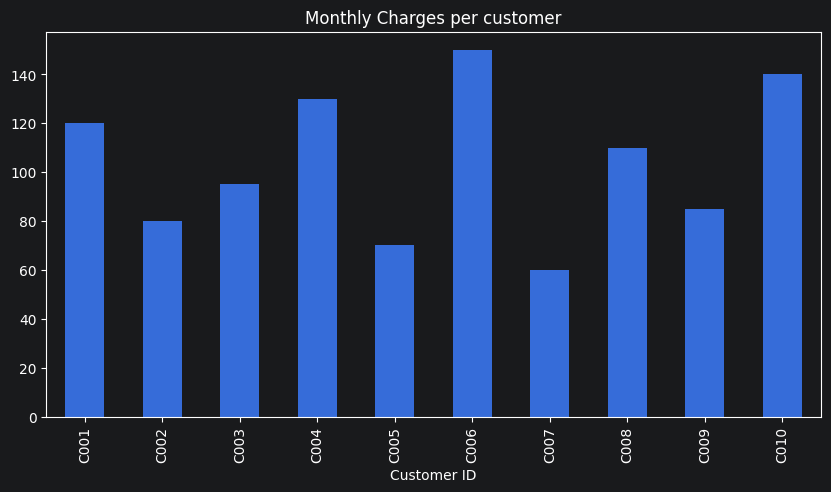

The customer with the highest charges
Customer ID                 C006
Monthly Charges              150
Contract Length (Months)       2
Internet Usage (GB)          450
Support Tickets                7
Churn                          1
Name: 5, dtype: object


In [402]:
# Identify the highest monthly charge.
plt.figure(figsize=(10,5))
plt.title("Monthly Charges per customer")
df.set_index("Customer ID")["Monthly Charges"].plot(kind="bar")
plt.show()

highest_monthly = df.loc[df["Monthly Charges"].idxmax()]

print("The customer with the highest charges")
print(highest_monthly)


In [403]:
# Identify the average internet usage.
print("The average Internet usage is: ", df["Internet Usage (GB)"].mean())

The average Internet usage is:  264.0


# Part C - Data Splitting

In [404]:
# Split the dataset into: 70/30
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.3,
    random_state=42,
)

print("Training Data:", len(X_train))
print("Testing Data:", len(X_test))

Training Data: 7
Testing Data: 3


# Part D - Decision Tree Modeling Development

In [405]:
# Create DecisionTreeClassifier
# Configure: Criterion "gini", max depth 3
model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

model
# if nothing shows then uncomment
# print(model)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [406]:
# Train the model using .fit()
model.fit(X_train, Y_train)
print("Model training complete.")


Model training complete.


# Part E - Prediction and Evaluation

In [407]:
# Predict test data
y_prediction = model.predict(X_test)

print("Predictions:", y_prediction)

Predictions: [0 0 1]


In [408]:
# Compute the accuracy score
accuracy = accuracy_score(Y_test, y_prediction)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [409]:
# Compute the confusion matrix
cm = confusion_matrix(Y_test, y_prediction)

print("Confusion Matrix:")
print(*cm, sep="\n")

Confusion Matrix:
[2 0]
[0 1]


The True negative is: 2, and false positive is 0

The False negative is: 0, and true positive is 1

Therefore, the model accurately predicted the customers that churned.

In [410]:
# Compute the classification report
report = classification_report(
    Y_test,
    y_prediction,
    target_names=pd.Series(["No", "Yes"])
)

print(report)

              precision    recall  f1-score   support

          No       1.00      1.00      1.00         2
         Yes       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



Key Insights
- High precision: Model accurately predicts customers that churns and doens't
- High Recall: Model accurately identified all positive instances.
- High F1-Score: Each class is balanced.

# Part F - Data Visualization

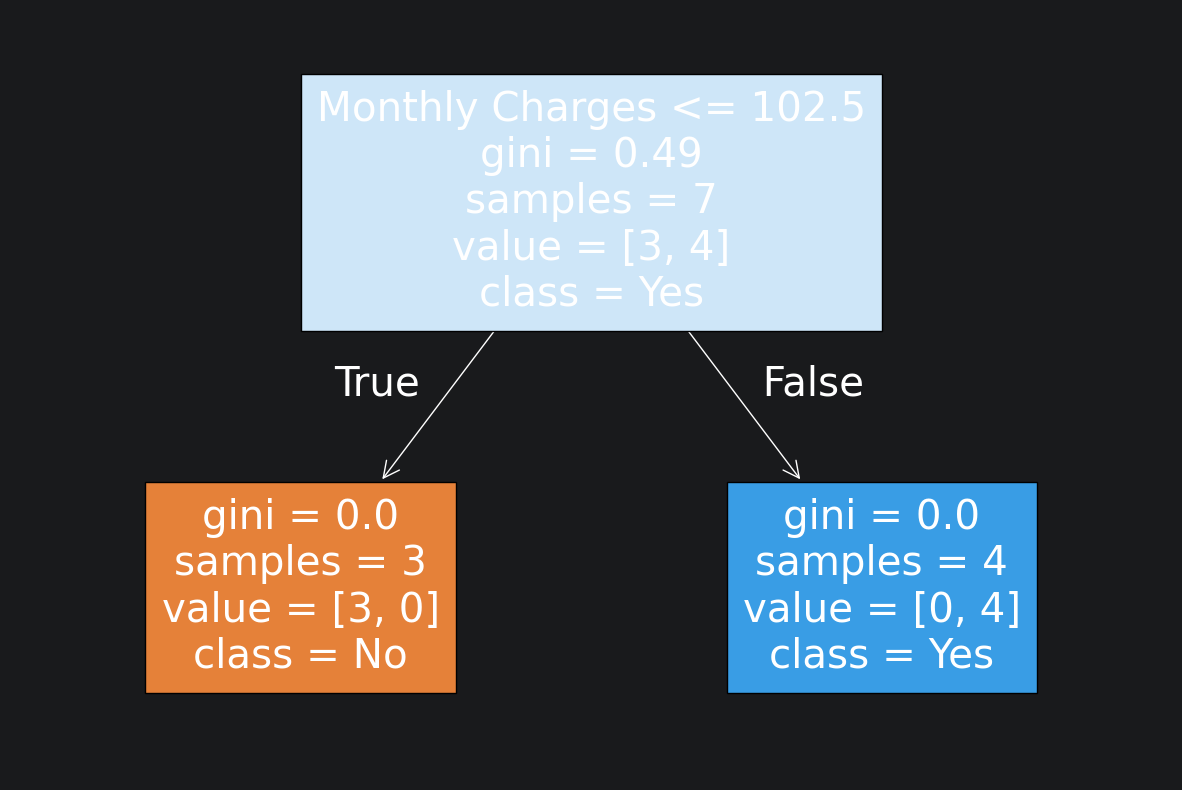

In [411]:
# Visualize the decision tree
plt.figure(figsize=(15,10))

plot_tree(
    model,
    feature_names=pd.Series(X.columns),
    class_names=pd.Series(["No", "Yes"]),
    filled=True,
)

plt.show()



# Part G - Feature Importance Analysis

In [412]:
# Display feature importance
# Rank Influential variables
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_,
})

importance.sort_values(by="Importance", ascending=False)

,Feature,Importance
0,Monthly Charges,1.0
1,Contract Length (Months),0.0
2,Internet Usage (GB),0.0
3,Support Tickets,0.0


Based on the model and criterion, the main deciding factor whether the customer will churn is based solely on Internet Usage (GB)

# Part H - Overfitting Experiment

In [413]:
# Create another decision tree without max_depth

overfit_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=42,
)

print(overfit_model)

# Training the model

overfit_model.fit(X_train, Y_train)
print("Model training complete.")

# Generating predictions

overfit_predictions = overfit_model.predict(X_test)
overfit_accuracy = accuracy_score(Y_test, overfit_predictions)
print("Overfitted Model:", overfit_accuracy)

DecisionTreeClassifier(random_state=42)
Model training complete.
Overfitted Model: 1.0


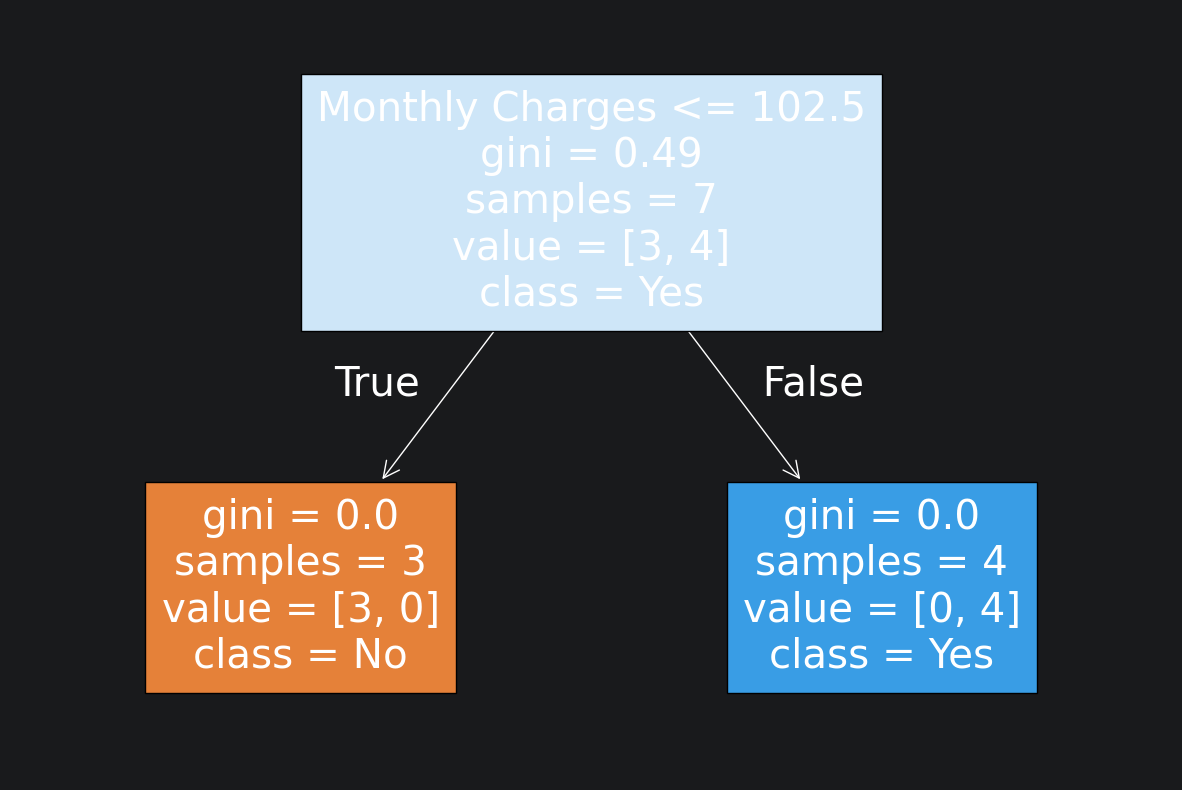

In [414]:
# Visualize the decision tree
plt.figure(figsize=(15,10))

plot_tree(
    overfit_model,
    feature_names=pd.Series(X.columns),
    class_names=pd.Series(["No", "Yes"]),
    filled=True,
)

plt.show()

In [415]:
# Comparing controlled vs overfit
print("Controlled accuracy", accuracy)
print("Overfitted accuracy", overfit_accuracy)

Controlled accuracy 1.0
Overfitted accuracy 1.0
